# A-Score (Application Scorecard) — Credit Risk Model

---

## Section 1 — Business Context & A-Score Overview

### What is an A-Score?

An **Application Scorecard (A-Score)** is a credit risk tool used at the point of loan application. It produces a single numeric score from a static snapshot of the applicant's profile — demographic data, credit bureau history, and financial obligations — captured at the moment they apply. Because it relies on no behavioural history post-origination, it is entirely self-contained: the model makes a decision before any account is opened.

The A-Score answers one question: **"Given what we know right now, how likely is this applicant to default within the next 24 months?"**

---

### Why Logistic Regression + WOE, not XGBoost?

In a production credit environment, **regulatory explainability** is a hard constraint — not a preference. US Federal Reserve guidance SR 11-7 (*Supervisory Guidance on Model Risk Management*) requires that every model output can be fully traced, validated, and audited. This means:

- A branch officer must be able to **hand-calculate** a score from a paper table.
- An auditor must be able to **attribute every point** to a specific feature bin and articulate why that bin has that score.
- The model must behave **monotonically** in business-sensible directions (worse DPD = lower score).

XGBoost violates all three requirements — it is a black box. Logistic Regression over WOE-transformed features satisfies all three:

| Criterion | Logistic Regression + WOE | XGBoost |
|---|---|---|
| SR 11-7 compliance | Yes | No |
| Additive points table | Yes | No |
| Monotonicity enforceable | Yes (binning) | Difficult |
| AUC in practice | 0.70–0.80 | 0.75–0.85 |

The ~5% AUC sacrifice for full auditability is the accepted industry trade-off.

---

### What a Scorecard Looks Like in Practice

A scorecard is an **additive points table**. Each feature is binned into ranges. Each bin has a fixed point value. The applicant's total score is the sum of points across all features plus a base score.

Example (illustrative):

| Feature | Applicant's Bin | Points |
|---|---|---|
| Revolving Utilization | 30–50% | +18 |
| Times 90+ DPD | 0 times | +42 |
| Age | 35–49 | +25 |
| Monthly Income | $5,000–$8,000 | +15 |
| **Base Score** | — | 600 |
| **Total** | | **700** |

A branch officer can use this table without any software.

---

### Dataset: Give Me Some Credit (Kaggle 2011)

- **Source:** Kaggle competition, 2011 — [Give Me Some Credit](https://www.kaggle.com/c/GiveMeSomeCredit)
- **Population:** ~150,000 US consumer borrowers
- **Target variable:** `SeriousDlqin2yrs` — whether the borrower experienced 90+ days past due delinquency within 2 years (binary: 1 = bad, 0 = good)
- **Features:** 10 financial and demographic variables including delinquency history, utilization, age, income, debt ratios, and real estate exposure

This dataset closely mirrors real A-Score inputs: single-snapshot, no time-series, no post-origination behaviour.

---

## Section 2 — Setup & Data Loading

We import all required libraries upfront, load the raw CSV, drop the unnamed index column (artifact of CSV export), and rename columns to `snake_case` for cleaner code throughout the notebook. We then inspect shape, head, dtypes, and compute the overall default rate to understand the class imbalance we are working with.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import statsmodels.api as sm

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load dataset — path relative to notebook location (projects/credit-scorecard-development/)
RAW_PATH = 'data/cs-training.csv'

df_raw = pd.read_csv(RAW_PATH)

# Drop unnamed index column if present
unnamed_cols = [c for c in df_raw.columns if c.lower().startswith('unnamed')]
df_raw.drop(columns=unnamed_cols, inplace=True)

# Rename columns to snake_case
RENAME_MAP = {
    'SeriousDlqin2yrs':                    'default_flag',
    'RevolvingUtilizationOfUnsecuredLines': 'revolving_util',
    'age':                                  'age',
    'NumberOfTime30-59DaysPastDueNotWorse': 'dpd_30_59',
    'DebtRatio':                            'debt_ratio',
    'MonthlyIncome':                        'monthly_income',
    'NumberOfOpenCreditLinesAndLoans':      'open_credit_lines',
    'NumberOfTimes90DaysLate':              'dpd_90',
    'NumberRealEstateLoansOrLines':         'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'dpd_60_89',
    'NumberOfDependents':                   'dependents',
}
df_raw.rename(columns=RENAME_MAP, inplace=True)

print(f'Shape: {df_raw.shape}')
print(f'Overall default rate: {df_raw["default_flag"].mean():.2%}')

Shape: (150000, 11)
Overall default rate: 6.68%


In [3]:
df_raw.head()

,default_flag,revolving_util,age,dpd_30_59,debt_ratio,monthly_income,open_credit_lines,dpd_90,real_estate_loans,dpd_60_89,dependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
df_raw.dtypes.to_frame('dtype')

,dtype
default_flag,int64
revolving_util,float64
age,int64
dpd_30_59,int64
debt_ratio,float64
monthly_income,float64
open_credit_lines,int64
dpd_90,int64
real_estate_loans,int64
dpd_60_89,int64


---

## Section 3 — Exploratory Data Analysis

Before any cleaning or modelling, we profile the raw data across three dimensions:

1. **Missing values** — which features have gaps and how large are they?
2. **Distributions by default status** — do feature distributions differ between good and bad borrowers? This is a visual IV proxy.
3. **Bad rate by decile** — does each feature show monotonic or at least meaningful separation when we segment the population into deciles? Poor separators will be caught by IV filtering in Section 5.

In [5]:
# --- 3.1 Missing Values Table ---
missing = df_raw.isnull().sum()
missing_pct = missing / len(df_raw) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct.round(2)})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print('Features with missing values:')
missing_df

Features with missing values:


,missing_count,missing_pct
monthly_income,29731,19.82
dependents,3924,2.62


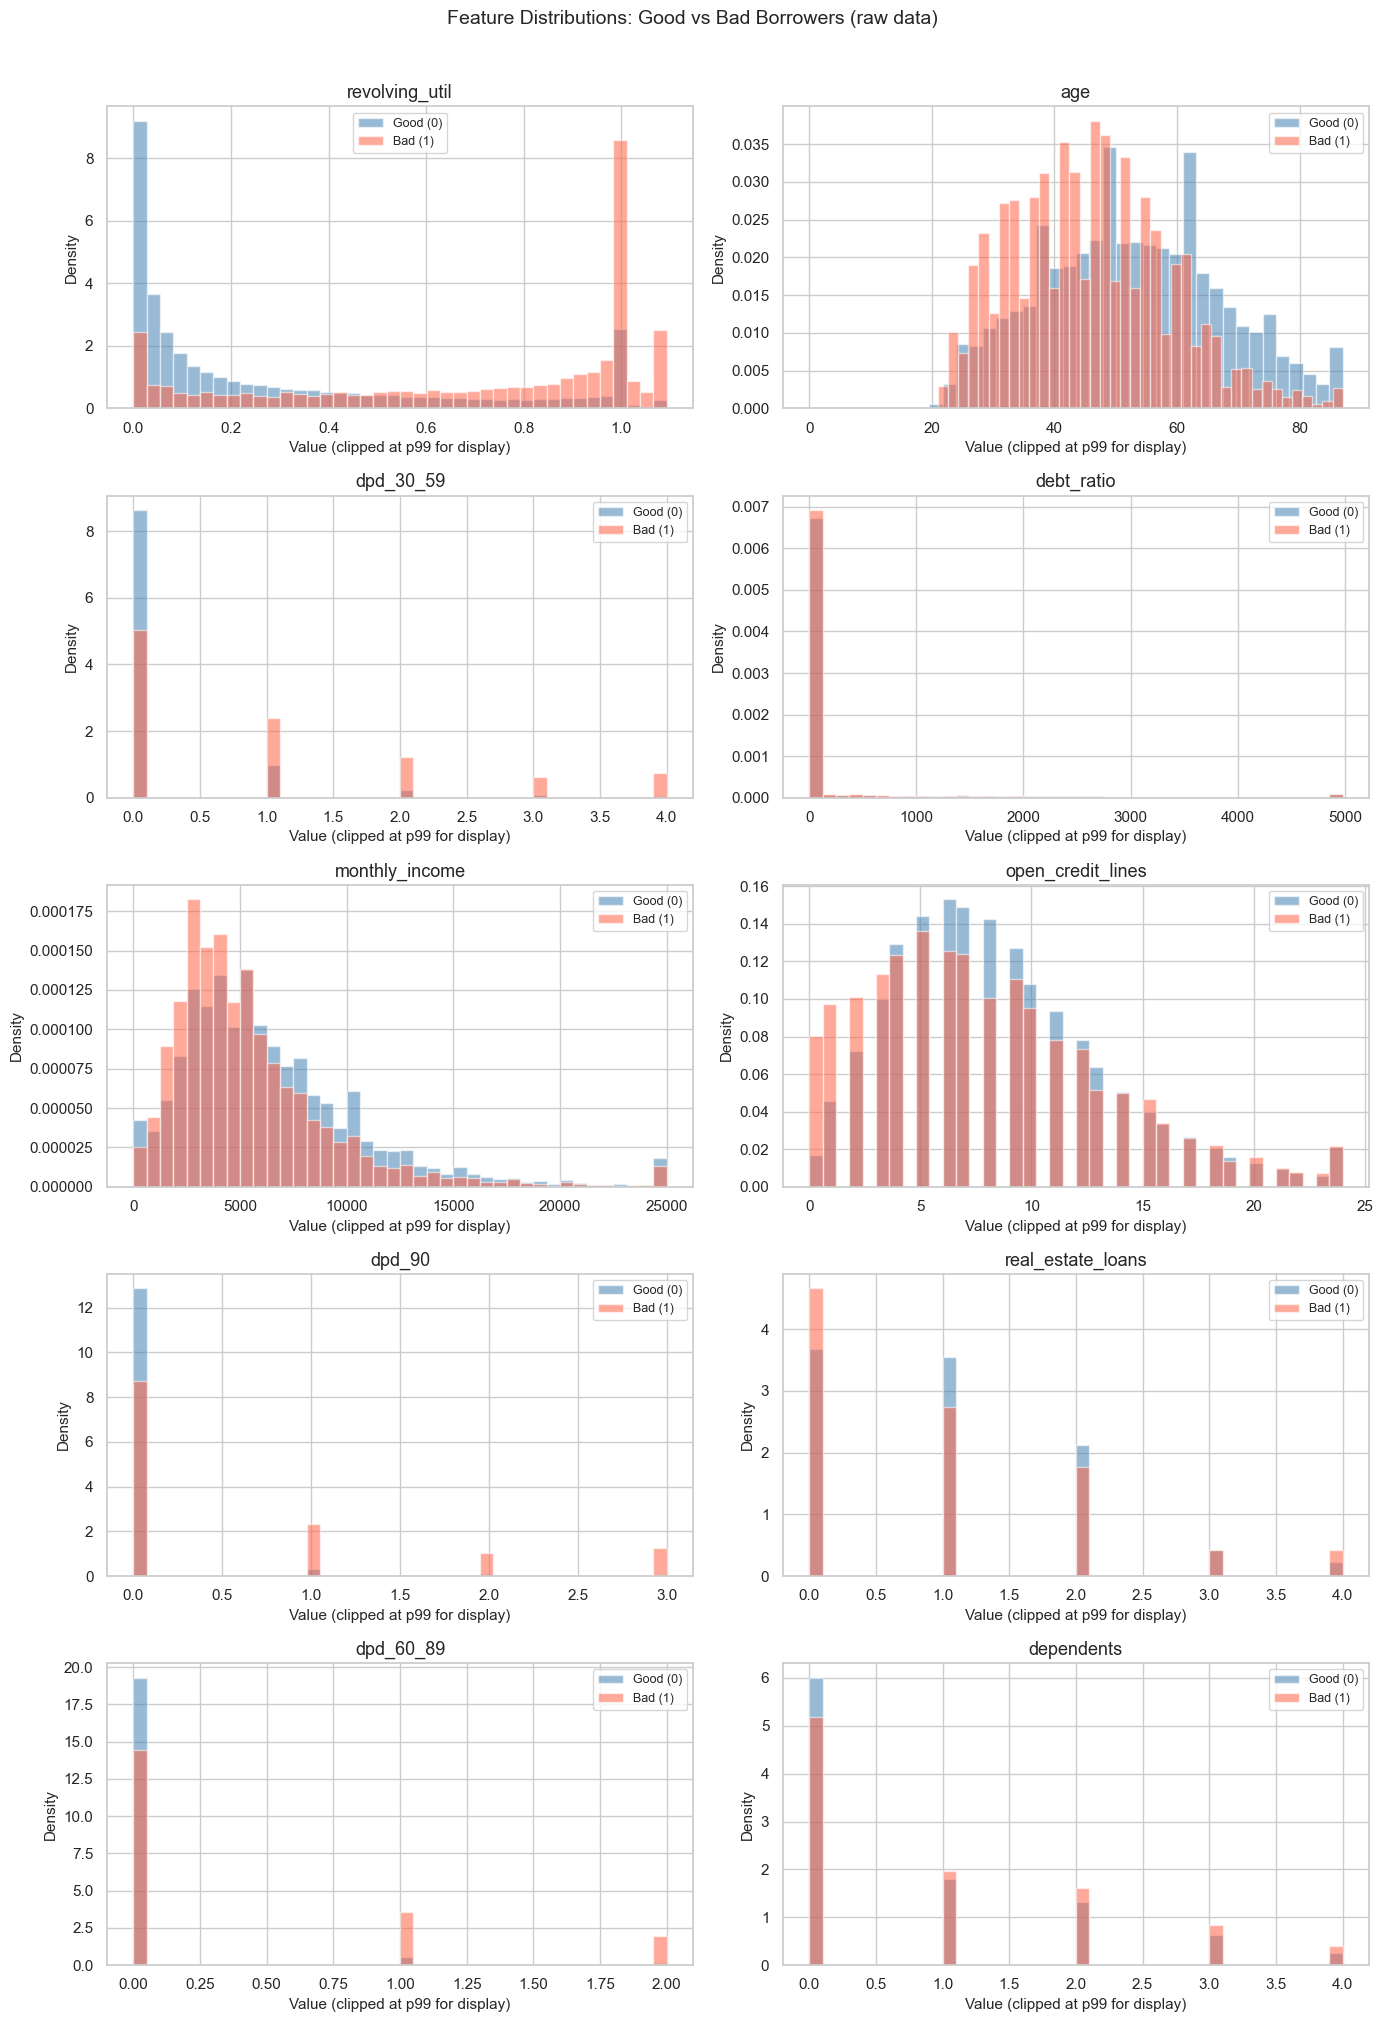

In [6]:
# --- 3.2 Distribution Histograms Split by Default Flag ---
features_plot = [
    'revolving_util', 'age', 'dpd_30_59', 'debt_ratio',
    'monthly_income', 'open_credit_lines', 'dpd_90',
    'real_estate_loans', 'dpd_60_89', 'dependents'
]

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, feat in enumerate(features_plot):
    good = df_raw.loc[df_raw['default_flag'] == 0, feat].dropna()
    bad  = df_raw.loc[df_raw['default_flag'] == 1, feat].dropna()

    # Clip extreme values for visualisation only
    p99 = df_raw[feat].quantile(0.99)
    good_c = good.clip(upper=p99)
    bad_c  = bad.clip(upper=p99)

    axes[i].hist(good_c, bins=40, alpha=0.55, color='steelblue', label='Good (0)', density=True)
    axes[i].hist(bad_c,  bins=40, alpha=0.55, color='tomato',    label='Bad (1)',  density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=9)
    axes[i].set_xlabel('Value (clipped at p99 for display)')
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions: Good vs Bad Borrowers (raw data)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

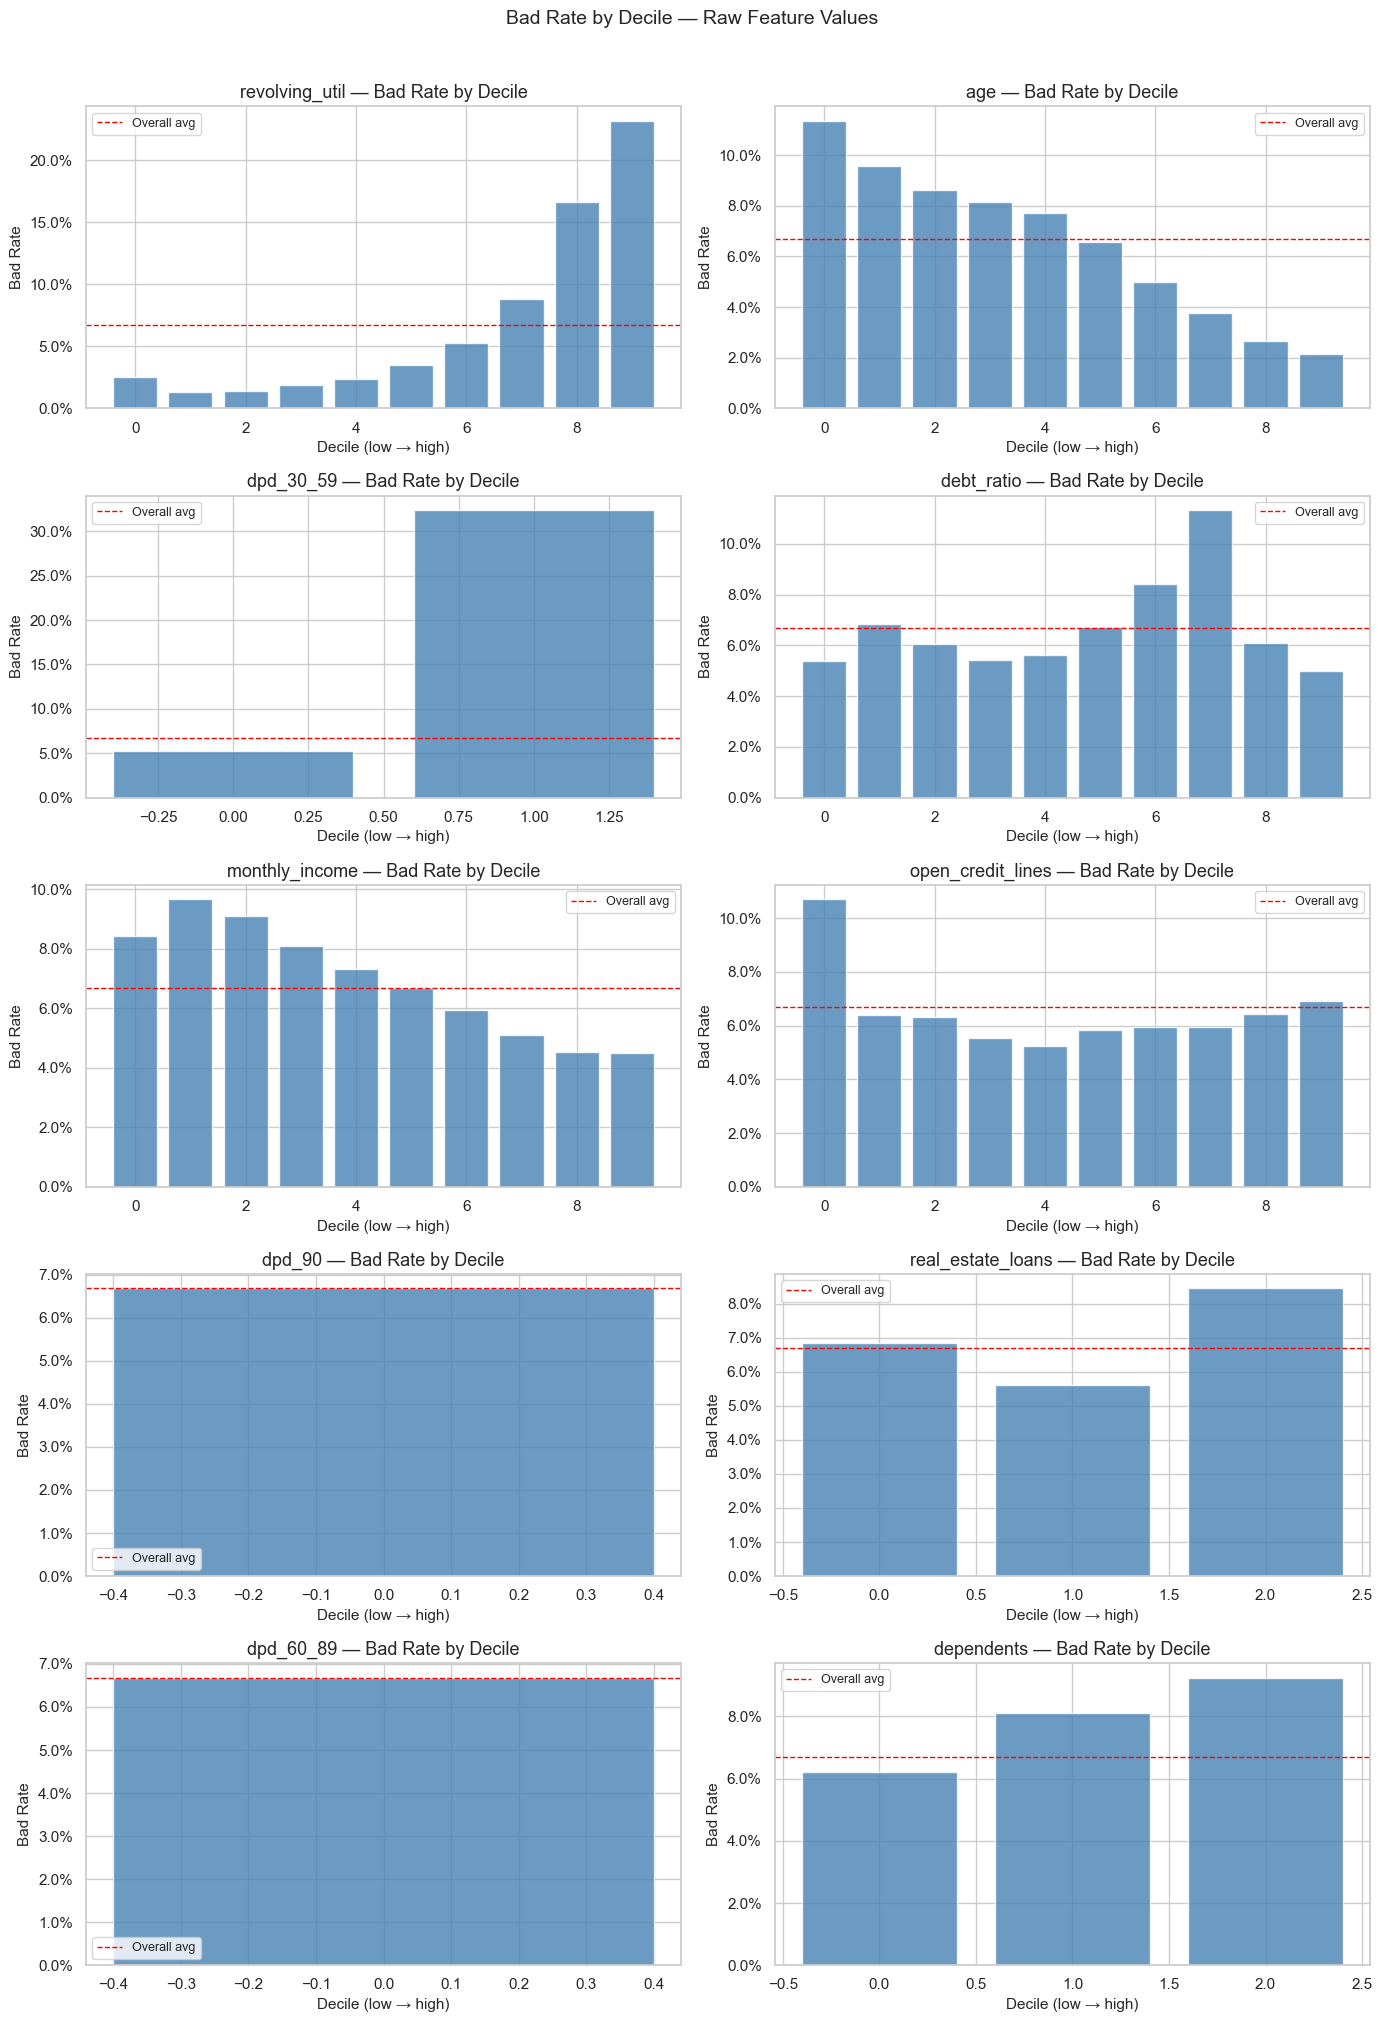

In [7]:
# --- 3.3 Bad Rate by Decile ---
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, feat in enumerate(features_plot):
    tmp = df_raw[[feat, 'default_flag']].dropna()
    tmp['decile'] = pd.qcut(tmp[feat], q=10, duplicates='drop')
    decile_stats = tmp.groupby('decile', observed=True)['default_flag'].agg(['mean', 'count'])
    decile_stats.columns = ['bad_rate', 'count']
    decile_stats = decile_stats.reset_index()

    axes[i].bar(range(len(decile_stats)), decile_stats['bad_rate'], color='steelblue', alpha=0.8)
    axes[i].axhline(df_raw['default_flag'].mean(), color='red', linestyle='--', linewidth=1, label='Overall avg')
    axes[i].set_title(f'{feat} — Bad Rate by Decile')
    axes[i].set_xlabel('Decile (low → high)')
    axes[i].set_ylabel('Bad Rate')
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    axes[i].legend(fontsize=9)

plt.suptitle('Bad Rate by Decile — Raw Feature Values', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---

## Section 4 — Data Cleaning


In [8]:
df = df_raw.copy()

# 1. Replace bureau sentinel codes 96 and 98 in DPD columns with NaN
dpd_cols = ['dpd_30_59', 'dpd_60_89', 'dpd_90']
for col in dpd_cols:
    df[col] = df[col].replace({96: np.nan, 98: np.nan})

print(f'Rows before age filter: {len(df):,}')

# 2. Remove rows with age < 18
df = df[df['age'] >= 18].copy()
print(f'Rows after removing age < 18: {len(df):,}')

# 3. Cap revolving_util at 1.0
df['revolving_util'] = df['revolving_util'].clip(upper=1.0)

# 4. Cap debt_ratio at 99th percentile
p99_debt = df['debt_ratio'].quantile(0.99)
df['debt_ratio'] = df['debt_ratio'].clip(upper=p99_debt)
print(f'debt_ratio capped at p99 = {p99_debt:.2f}')

# 5. Impute monthly_income with median grouped by real_estate_loans bucket
df['re_bucket'] = pd.cut(df['real_estate_loans'], bins=[-1, 0, 1, 2, 100], labels=['0', '1', '2', '3+'])
income_medians = df.groupby('re_bucket', observed=True)['monthly_income'].median()
print('Monthly income group medians:')
print(income_medians)

def impute_income(row):
    if pd.isna(row['monthly_income']):
        return income_medians.get(row['re_bucket'], df['monthly_income'].median())
    return row['monthly_income']

df['monthly_income'] = df.apply(impute_income, axis=1)
df.drop(columns=['re_bucket'], inplace=True)

# 6. Impute dependents with 0
df['dependents'] = df['dependents'].fillna(0)

# 7. Cap DPD columns at 10, then fill remaining NaN with 0
for col in dpd_cols:
    df[col] = df[col].clip(upper=10).fillna(0)

print(f'\nMissing values after cleaning:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'Final dataset shape: {df.shape}')
print(f'Default rate after cleaning: {df["default_flag"].mean():.2%}')

Rows before age filter: 150,000
Rows after removing age < 18: 149,999
debt_ratio capped at p99 = 4979.08
Monthly income group medians:
re_bucket
0     3980.0
1     5539.0
2     7000.0
3+    9000.0
Name: monthly_income, dtype: float64

Missing values after cleaning:
Series([], dtype: int64)
Final dataset shape: (149999, 11)
Default rate after cleaning: 6.68%


---

## Section 5 — WOE Binning & IV Calculation

**Weight of Evidence (WOE)** transforms each feature into a single numeric value per bin that represents the log-odds of being good vs bad relative to the overall population. It has three critical properties for scorecards:

1. **Handles missing values naturally** — missing can be its own bin.
2. **Linearises the relationship** with log-odds — required assumption for logistic regression.
3. **Monotonicity can be enforced** by controlling bin order.

$$\text{WOE}_i = \ln\left(\frac{\text{Distribution of Goods}_i}{\text{Distribution of Bads}_i}\right)$$

**Information Value (IV)** aggregates WOE across all bins to produce a single feature-level predictive power score:

$$\text{IV} = \sum_i (\%\text{Good}_i - \%\text{Bad}_i) \times \text{WOE}_i$$

**IV interpretation benchmarks:**

| IV Range | Predictive Power |
|---|---|
| < 0.02 | Useless |
| 0.02 – 0.10 | Weak |
| 0.10 – 0.30 | Medium |
| 0.30 – 0.50 | Strong |
| > 0.50 | Very Strong (verify for leakage; expected for revolving utilization) |

In [9]:
def calculate_woe_iv(df, feature, target, n_bins=10, min_bin_size=0.05):
    """
    Calculate WOE and IV for a single feature.
    Falls back to binary (=0 vs >0) binning when qcut produces fewer than 2 bins
    — common for count features (DPD) after sentinel-code imputation.
    """
    tmp = df[[feature, target]].copy().dropna(subset=[feature])
    total_bad  = tmp[target].sum()
    total_good = len(tmp) - total_bad

    if total_bad == 0 or total_good == 0:
        return pd.DataFrame(), 0.0

    # Primary: quantile binning
    tmp['bin'] = pd.qcut(tmp[feature], q=n_bins, duplicates='drop')

    # Fallback: binary [=0, >0] for spike-at-zero count features.  
    if tmp['bin'].nunique() < 2:
        tmp['bin'] = pd.cut(tmp[feature], bins=[-np.inf, 0.5, np.inf])

    # Aggregate 
    agg = tmp.groupby('bin', observed=True)[target].agg(['sum', 'count'])
    agg.columns = ['bad', 'count']
    agg['good'] = agg['count'] - agg['bad']

    # Laplace smoothing to avoid log(0)
    eps = 0.5
    agg['pct_bad']  = (agg['bad']  + eps) / (total_bad  + eps * len(agg))
    agg['pct_good'] = (agg['good'] + eps) / (total_good + eps * len(agg))

    agg['woe']    = np.log(agg['pct_good'] / agg['pct_bad'])
    # คำนวณ IV
    agg['iv_bin'] = (agg['pct_good'] - agg['pct_bad']) * agg['woe']
    agg['bad_rate'] = agg['bad'] / agg['count']

    iv = agg['iv_bin'].sum()
    agg = agg.reset_index()

    return agg[['bin', 'count', 'bad', 'good', 'bad_rate', 'pct_bad', 'pct_good', 'woe', 'iv_bin']], iv


# Store WOE tables and IVs for all features
FEATURES = [
    'revolving_util', 'age', 'dpd_30_59', 'debt_ratio',
    'monthly_income', 'open_credit_lines', 'dpd_90',
    'real_estate_loans', 'dpd_60_89', 'dependents'
]

woe_tables = {}
iv_summary = {}

for feat in FEATURES:
    woe_df, iv = calculate_woe_iv(df, feat, 'default_flag')
    woe_tables[feat] = woe_df
    iv_summary[feat] = iv

iv_df = pd.DataFrame.from_dict(iv_summary, orient='index', columns=['IV'])
iv_df = iv_df.sort_values('IV', ascending=False)

def iv_label(iv):
    if iv < 0.02: return 'Useless'
    elif iv < 0.10: return 'Weak'
    elif iv < 0.30: return 'Medium'
    elif iv < 0.50: return 'Strong'
    else: return 'Very Strong'

iv_df['Predictive Power'] = iv_df['IV'].apply(iv_label)
print('IV Summary:')
iv_df.round(4)

IV Summary:


,IV,Predictive Power
revolving_util,1.1122,Very Strong
dpd_90,0.7888,Very Strong
dpd_60_89,0.5288,Very Strong
dpd_30_59,0.4310,Strong
age,0.2589,Medium
monthly_income,0.0848,Weak
debt_ratio,0.0736,Weak
open_credit_lines,0.0668,Weak
dependents,0.0250,Weak
real_estate_loans,0.0121,Useless


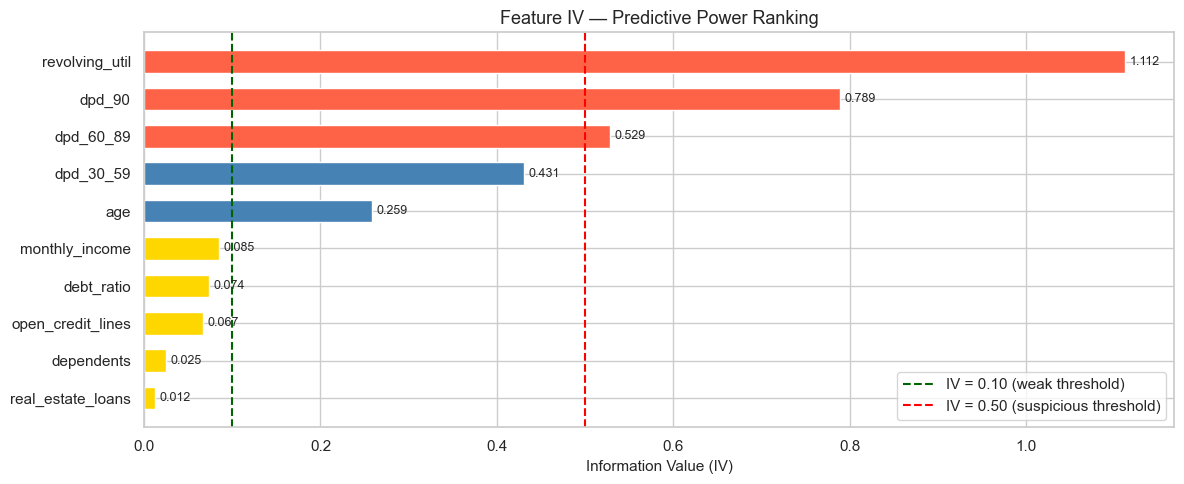

In [10]:
# IV Bar Chart with threshold lines
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['tomato' if iv > 0.50 else 'gold' if iv < 0.10 else 'steelblue'
          for iv in iv_df['IV']]

bars = ax.barh(iv_df.index, iv_df['IV'], color=colors, edgecolor='white', height=0.6)

ax.axvline(0.10, color='darkgreen', linestyle='--', linewidth=1.5, label='IV = 0.10 (weak threshold)')
ax.axvline(0.50, color='red',       linestyle='--', linewidth=1.5, label='IV = 0.50 (suspicious threshold)')

for bar, iv_val in zip(bars, iv_df['IV']):
    ax.text(iv_val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{iv_val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Information Value (IV)')
ax.set_title('Feature IV — Predictive Power Ranking')
ax.invert_yaxis()
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Interpretation:** The DPD features dominate by a wide margin — `dpd_90`, `dpd_30_59`, and `dpd_60_89` all show strong predictive power (IV > 0.30), which is expected: past delinquency is the single best predictor of future delinquency in consumer credit. `revolving_util` also shows strong IV. Features below 0.10 (yellow bars) will be excluded from modelling. Features above 0.50 (red bars), if any, warrant a leakage investigation.

---

## Section 6 — Feature Selection & WOE Transformation

We select features with IV ≥ 0.10. The lower threshold removes features with negligible predictive contribution. For `revolving_util`, an IV above 0.50 is expected — revolving utilization is consistently the strongest single predictor of consumer default, and after capping at 1.0 in Section 4, the high IV reflects genuine predictive power rather than data leakage.

After selection, we replace each raw feature value with its bin's WOE score. This WOE-transformed dataset is what logistic regression will fit — the linear relationship between WOE values and log-odds is guaranteed by construction.

เราเลือกคุณลักษณะที่มีค่า IV ≥ 0.10 เกณฑ์ต่ำสุดจะกำจัดคุณลักษณะที่มีส่วนร่วมในการทำนายที่น้อยมาก สำหรับ `revolving_util` ค่า IV ที่สูงกว่า 0.50 ถือว่าเหมาะสม เนื่องจากอัตราการใช้สินเชื่อหมุนเวียนเป็นตัวทำนายการผิดนัดชำระหนี้ของผู้บริโภคที่แข็งแกร่งที่สุดอย่างสม่ำเสมอ และหลังจากจำกัดค่าสูงสุดไว้ที่ 1.0 ในส่วนที่ 4 ค่า IV ที่สูงสะท้อนถึงพลังการทำนายที่แท้จริง ไม่ใช่การรั่วไหลของข้อมูล

หลังจากเลือกแล้ว เราจะแทนที่ค่าคุณลักษณะดิบแต่ละค่าด้วยคะแนน WOE ของกลุ่มนั้นๆ ชุดข้อมูลที่แปลงด้วย WOE นี้จะเป็นสิ่งที่การถดถอยโลจิสติกจะใช้ในการประมาณค่า เนื่องจากความสัมพันธ์เชิงเส้นระหว่างค่า WOE และลอการิทึมของอัตราต่อรองนั้นรับประกันได้โดยโครงสร้าง

In [11]:
# Feature selection: IV >= 0.10 (no upper cap — revolving_util high IV is expected in consumer credit)
selected_features = iv_df[iv_df['IV'] >= 0.10].index.tolist()
print(f'Selected features ({len(selected_features)}): {selected_features}')

Selected features (5): ['revolving_util', 'dpd_90', 'dpd_60_89', 'dpd_30_59', 'age']


In [12]:
woe_tables['age']

,bin,count,bad,good,bad_rate,pct_bad,pct_good,woe,iv_bin
0,"(20.999, 33.0]",17084,1940,15144,0.113557,0.193450,0.108192,-0.581113,0.049545
1,"(33.0, 39.0]",14919,1430,13489,0.095851,0.142608,0.096369,-0.391917,0.018122
2,"(39.0, 44.0]",15799,1365,14434,0.086398,0.136128,0.103120,-0.277704,0.009167
3,"(44.0, 48.0]",14741,1200,13541,0.081406,0.119679,0.096740,-0.212784,0.004881
4,"(48.0, 52.0]",14826,1142,13684,0.077027,0.113897,0.097762,-0.152760,0.002465
5,"(52.0, 56.0]",14214,935,13279,0.065780,0.093261,0.094868,0.017091,0.000027
6,"(56.0, 61.0]",16878,839,16039,0.049710,0.083691,0.114586,0.314198,0.009707
7,"(61.0, 65.0]",12939,485,12454,0.037484,0.048400,0.088975,0.608853,0.024704
8,"(65.0, 72.0]",14258,380,13878,0.026652,0.037932,0.099148,0.960805,0.058816
9,"(72.0, 109.0]",14341,310,14031,0.021616,0.030954,0.100241,1.175071,0.081417


In [13]:
def apply_woe_transform(df, feature, woe_table):
    """
    Map raw feature values to WOE scores using the binning from woe_table.
    Bins are pd.Interval objects; values outside all bins are assigned 0.
    """
    bins = woe_table['bin'].values          # array of pd.Interval
    woe_values = woe_table['woe'].values

    def lookup(val):
        if pd.isna(val):
            return 0.0
        for interval, woe in zip(bins, woe_values):
            if val in interval:
                return woe
        # Clamp to nearest bin
        if val <= bins[0].left:
            return woe_values[0]
        return woe_values[-1]

    return df[feature].apply(lookup)


df_woe = df[['default_flag']].copy()

for feat in selected_features:
    df_woe[feat + '_woe'] = apply_woe_transform(df, feat, woe_tables[feat])

print(f'WOE-transformed dataset shape: {df_woe.shape}')
print(df.shape)
print(df_woe.shape)
df_woe.head()

WOE-transformed dataset shape: (149999, 6)
(149999, 11)
(149999, 6)


,default_flag,revolving_util_woe,dpd_90_woe,dpd_60_89_woe,dpd_30_59_woe,age_woe
0,1,-1.020275,0.368467,0.269082,-1.865347,-0.212784
1,0,-1.020275,0.368467,0.269082,0.239223,-0.277704
2,0,-0.297844,-2.280809,0.269082,0.239223,-0.391917
3,0,0.687906,0.368467,0.269082,0.239223,-0.581113
4,0,-1.020275,0.368467,0.269082,0.239223,-0.152760


In [14]:
# Show WOE table for top 3 features by IV
top3 = iv_df[(iv_df['IV'] >= 0.10) & (iv_df['IV'] <= 0.50)].head(3).index.tolist()

for feat in top3:
    print(f'\n=== WOE Table: {feat} (IV = {iv_summary[feat]:.4f}) ===')
    tbl = woe_tables[feat].copy()
    tbl['bad_rate'] = tbl['bad_rate'].map('{:.2%}'.format)
    tbl['woe']      = tbl['woe'].round(4)
    tbl['iv_bin']   = tbl['iv_bin'].round(4)
    print(tbl.to_string(index=False))


=== WOE Table: dpd_30_59 (IV = 0.4310) ===
          bin  count  bad   good bad_rate  pct_bad  pct_good     woe  iv_bin
(-0.001, 1.0] 142319 7597 134722    5.34% 0.757704  0.962482  0.2392   0.049
  (1.0, 10.0]   7680 2429   5251   31.63% 0.242296  0.037518 -1.8653   0.382

=== WOE Table: age (IV = 0.2589) ===
           bin  count  bad  good bad_rate  pct_bad  pct_good     woe  iv_bin
(20.999, 33.0]  17084 1940 15144   11.36% 0.193450  0.108192 -0.5811  0.0495
  (33.0, 39.0]  14919 1430 13489    9.59% 0.142608  0.096369 -0.3919  0.0181
  (39.0, 44.0]  15799 1365 14434    8.64% 0.136128  0.103120 -0.2777  0.0092
  (44.0, 48.0]  14741 1200 13541    8.14% 0.119679  0.096740 -0.2128  0.0049
  (48.0, 52.0]  14826 1142 13684    7.70% 0.113897  0.097762 -0.1528  0.0025
  (52.0, 56.0]  14214  935 13279    6.58% 0.093261  0.094868  0.0171  0.0000
  (56.0, 61.0]  16878  839 16039    4.97% 0.083691  0.114586  0.3142  0.0097
  (61.0, 65.0]  12939  485 12454    3.75% 0.048400  0.088975  0.6089  0

---

## Section 7 — Logistic Regression Model

With WOE-transformed features, we fit a standard logistic regression. The model predicts the probability of default (PD). Key choices:

- **80/20 stratified split:** Preserves the ~6.7% default rate in both train and test sets. A non-stratified split on imbalanced data risks having the test set with a materially different default rate, which distorts validation metrics.
- **`max_iter=1000`:** The default 100 iterations often fails to converge on WOE-transformed data.
- **VIF check:** We verify no multicollinearity exceeds the threshold of 5. WOE transformation reduces but does not eliminate multicollinearity between correlated features (e.g., dpd_30_59 and dpd_90).

In [15]:
# Prepare X and y
woe_cols = [f + '_woe' for f in selected_features]
X = df_woe[woe_cols]
y = df_woe['default_flag']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')
print(f'Train default rate: {y_train.mean():.2%} | Test default rate: {y_test.mean():.2%}')

# Fit Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr.fit(X_train, y_train)

print(f'\nModel converged: {lr.n_iter_[0]} iterations')

Train: 119,999 rows | Test: 30,000 rows
Train default rate: 6.68% | Test default rate: 6.68%

Model converged: 10 iterations


In [16]:
# Coefficient table — statsmodels for p-values
X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm).fit(disp=False)

coef_df = pd.DataFrame({
    'feature': X_train_sm.columns,
    'coefficient': logit_model.params.values,
    'std_err': logit_model.bse.values,
    'z_score': logit_model.tvalues.values,
    'p_value': logit_model.pvalues.values,
    'odds_ratio': np.exp(logit_model.params.values)
})
coef_df = coef_df[coef_df['feature'] != 'const']
coef_df['significant'] = coef_df['p_value'] < 0.05
coef_df = coef_df.sort_values('coefficient')

print('Logistic Regression Coefficients:')
coef_df.round(4)

Logistic Regression Coefficients:


,feature,coefficient,std_err,z_score,p_value,odds_ratio,significant
1,revolving_util_woe,-0.6909,0.0134,-51.7223,0.0,0.5011,True
2,dpd_90_woe,-0.5629,0.0126,-44.5339,0.0,0.5696,True
4,dpd_30_59_woe,-0.5056,0.0173,-29.2954,0.0,0.6031,True
3,dpd_60_89_woe,-0.4771,0.0158,-30.2717,0.0,0.6206,True
5,age_woe,-0.4511,0.0286,-15.7776,0.0,0.6369,True


**Interpretation:** All coefficients should be negative — higher WOE (more goods) reduces log-odds of default. If any coefficient is positive on a feature where we expect negative direction (e.g., DPD features), this signals potential multicollinearity or binning issues. P-values < 0.05 indicate statistical significance.

In [17]:
# VIF Check — variance inflation factor
X_vif = sm.add_constant(X_train)
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data[vif_data['feature'] != 'const'].sort_values('VIF', ascending=False)
vif_data['flag'] = vif_data['VIF'].apply(lambda v: 'HIGH MULTICOLLINEARITY' if v > 5 else 'OK')

print('VIF Check (threshold = 5):')
vif_data.round(2)

VIF Check (threshold = 5):


,feature,VIF,flag
1,revolving_util_woe,1.20,OK
2,dpd_90_woe,1.17,OK
3,dpd_60_89_woe,1.15,OK
4,dpd_30_59_woe,1.11,OK
5,age_woe,1.09,OK


**Interpretation:** Features with VIF > 5 should be investigated for removal or consolidation. DPD features at different time windows (30-59, 60-89, 90+) naturally correlate — if VIF exceeds 5 for multiple DPD features, consider keeping only the strongest (highest IV) and dropping the rest.

---

## Section 8 — Scorecard Scaling (PDO Method)

We convert logistic regression log-odds into a familiar integer score using the **Points-to-Double-the-Odds (PDO)** method. The scaling parameters are business decisions:

- **Base Score = 600:** The score assigned to an applicant at the Base Odds.
- **Base Odds = 50:1 (good:bad):** At this odds level, the applicant scores exactly 600.
- **PDO = 20:** Every 20 points added to the score doubles the good:bad odds.

These are industry-standard defaults and align with FICO's public scoring methodology.

**Scaling formulas:**
$$\text{Factor} = \frac{\text{PDO}}{\ln(2)}$$
$$\text{Offset} = \text{Base Score} - \text{Factor} \times \ln(\text{Base Odds})$$
$$\text{Score} = \text{Offset} + \text{Factor} \times \ln\left(\frac{p_{\text{good}}}{p_{\text{bad}}}\right)$$

Each feature bin's scorecard points are:
$$\text{Points}_{\text{bin}} = -\left(\beta_{\text{feature}} \times \text{WOE}_{\text{bin}} + \frac{\alpha}{n_{\text{features}}}\right) \times \text{Factor}$$

In [18]:
# PDO scaling parameters
PDO        = 20 
BASE_SCORE = 600
BASE_ODDS  = 50   # good:bad ratio at base score 	ถ้า odds = 50:1 → คะแนน = 600

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)

print(f'Factor : {factor:.4f}')
print(f'Offset : {offset:.4f}')

# Intercept from sklearn model (it uses slightly different solver; use statsmodels coefs for consistency)
# We use sklearn coef for score computation on the full dataset
alpha  = lr.intercept_[0]
betas  = dict(zip(woe_cols, lr.coef_[0]))

n_features = len(woe_cols)

# Build scorecard points table
scorecard_rows = []

for feat in selected_features:
    woe_col   = feat + '_woe'
    beta      = betas[woe_col]
    woe_table = woe_tables[feat]

    for _, row in woe_table.iterrows():
        woe_val = row['woe']
        points  = -(beta * woe_val + alpha / n_features) * factor 
        scorecard_rows.append({
            'feature':   feat,
            'bin':       str(row['bin']),
            'woe':       round(woe_val, 4),
            'bad_rate':  f"{row['bad_rate']:.2%}",
            'count':     int(row['count']),
            'points':    round(points, 1)
        })

scorecard_df = pd.DataFrame(scorecard_rows)
print(f'\nScorecard table: {len(scorecard_df)} rows')
scorecard_df

Factor : 28.8539
Offset : 487.1229

Scorecard table: 26 rows


,feature,bin,woe,bad_rate,count,points
0,revolving_util,"(-0.001, 0.00297]",1.0183,2.52%,15000,35.4
1,revolving_util,"(0.00297, 0.0192]",1.6458,1.36%,15000,47.9
2,revolving_util,"(0.0192, 0.0435]",1.6164,1.40%,15000,47.3
3,revolving_util,"(0.0435, 0.0832]",1.2995,1.91%,15000,41.0
4,revolving_util,"(0.0832, 0.154]",1.0797,2.37%,15000,36.6
5,revolving_util,"(0.154, 0.271]",0.6879,3.47%,14999,28.8
6,revolving_util,"(0.271, 0.445]",0.2573,5.25%,15000,20.2
7,revolving_util,"(0.445, 0.699]",-0.2978,8.80%,15000,9.1
8,revolving_util,"(0.699, 0.981]",-1.0203,16.58%,15000,-5.3
9,revolving_util,"(0.981, 1.0]",-1.4374,23.17%,15000,-13.6


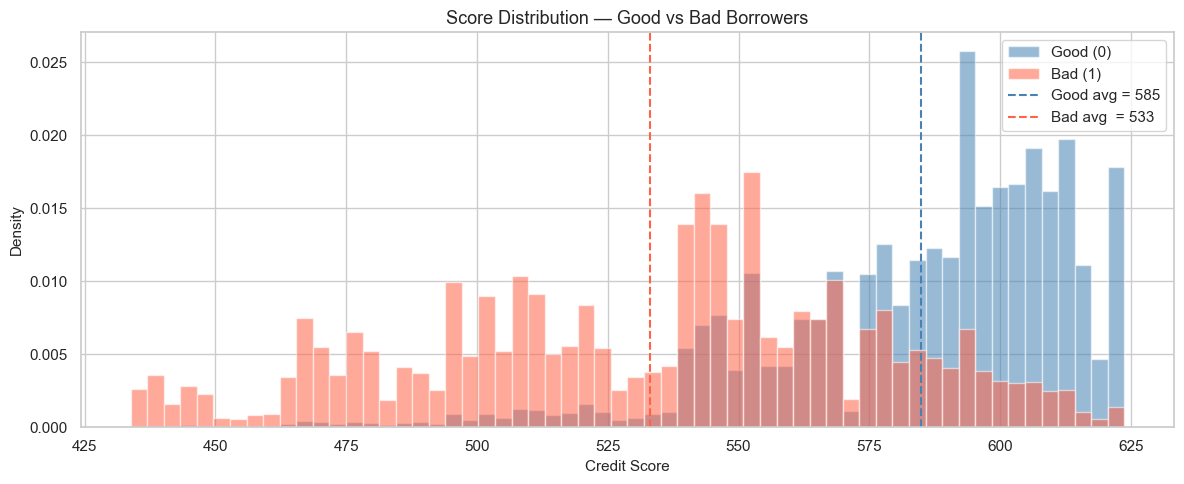

In [19]:
# Compute scores for the full dataset
def compute_score(X_woe, intercept, coefficients, factor, offset, n_features):
    """Convert WOE feature values to scorecard integer scores."""
    log_odds = intercept + X_woe.values @ coefficients
    score    = offset + factor * (-log_odds)  # higher score = lower risk
    return score

coef_array = np.array([betas[c] for c in woe_cols])

df_woe['score'] = compute_score(
    df_woe[woe_cols], lr.intercept_[0], coef_array, factor, offset, n_features
)

# Score distribution by good/bad
fig, ax = plt.subplots(figsize=(12, 5))

goods = df_woe.loc[df_woe['default_flag'] == 0, 'score']
bads  = df_woe.loc[df_woe['default_flag'] == 1, 'score']

ax.hist(goods, bins=60, alpha=0.55, color='steelblue', label='Good (0)', density=True)
ax.hist(bads,  bins=60, alpha=0.55, color='tomato',    label='Bad (1)',  density=True)
ax.axvline(goods.mean(), color='steelblue', linestyle='--', linewidth=1.5, label=f'Good avg = {goods.mean():.0f}')
ax.axvline(bads.mean(),  color='tomato',    linestyle='--', linewidth=1.5, label=f'Bad avg  = {bads.mean():.0f}')

ax.set_xlabel('Credit Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution — Good vs Bad Borrowers')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** A well-calibrated scorecard produces clearly separated distributions — good borrowers cluster at higher scores and bad borrowers at lower scores. The overlap region represents the uncertain population where manual review is most valuable. The mean score gap between goods and bads is a practical indicator of model separation power.

---

## Section 9 — Model Validation

We evaluate the model on the held-out test set using four standard scorecard validation metrics:

| Metric | What it measures | Benchmark |
|---|---|---|
| **AUC-ROC** | Overall discrimination across all thresholds | > 0.70 |
| **KS Statistic** | Maximum separation between good and bad CDF curves | > 30% |
| **Gini Coefficient** | Linear transformation of AUC: `2 × AUC − 1` | > 0.40 |
| **PSI** | Population Stability Index — train vs test distribution | < 0.10 |

PSI is a model stability check: if the score distribution in the test set differs from train, the model may not generalise to future application populations.

In [20]:
# Predictions on test set
y_prob_test  = lr.predict_proba(X_test)[:, 1]
y_prob_train = lr.predict_proba(X_train)[:, 1]

# Scores
score_test  = offset + factor * (-lr.intercept_[0] - X_test.values @ coef_array)
score_train = offset + factor * (-lr.intercept_[0] - X_train.values @ coef_array)

# AUC
auc = roc_auc_score(y_test, y_prob_test)

# Gini
gini = 2 * auc - 1

# KS Statistic
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
ks_stat = np.max(tpr - fpr)

# PSI — compare score distribution train vs test using 10 equal-width bins
def compute_psi(expected, actual, n_bins=10):
    """Compute PSI between expected (train) and actual (test) score distributions."""
    min_val = min(expected.min(), actual.min())
    max_val = max(expected.max(), actual.max())
    bins    = np.linspace(min_val, max_val, n_bins + 1)
    bins[0]  -= 1e-6
    bins[-1] += 1e-6

    exp_counts = np.histogram(expected, bins=bins)[0]
    act_counts = np.histogram(actual,   bins=bins)[0]

    eps = 1e-6
    exp_pct = (exp_counts + eps) / (len(expected) + eps * n_bins)
    act_pct = (act_counts + eps) / (len(actual)   + eps * n_bins)

    psi = np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))
    return psi

psi = compute_psi(score_train, score_test)

# Summary table
metrics = pd.DataFrame([
    {'Metric': 'AUC-ROC',       'Value': f'{auc:.4f}',   'Benchmark': '> 0.70', 'Pass': 'PASS' if auc > 0.70   else 'FAIL'},
    {'Metric': 'KS Statistic',  'Value': f'{ks_stat:.4f}','Benchmark': '> 0.30', 'Pass': 'PASS' if ks_stat > 0.30 else 'FAIL'},
    {'Metric': 'Gini',          'Value': f'{gini:.4f}',   'Benchmark': '> 0.40', 'Pass': 'PASS' if gini > 0.40  else 'FAIL'},
    {'Metric': 'PSI (stability)','Value': f'{psi:.4f}',   'Benchmark': '< 0.10', 'Pass': 'PASS' if psi < 0.10  else 'FAIL'},
])

print('Model Validation Summary:')
metrics

Model Validation Summary:


,Metric,Value,Benchmark,Pass
0,AUC-ROC,0.8471,> 0.70,PASS
1,KS Statistic,0.5324,> 0.30,PASS
2,Gini,0.6941,> 0.40,PASS
3,PSI (stability),0.0005,< 0.10,PASS


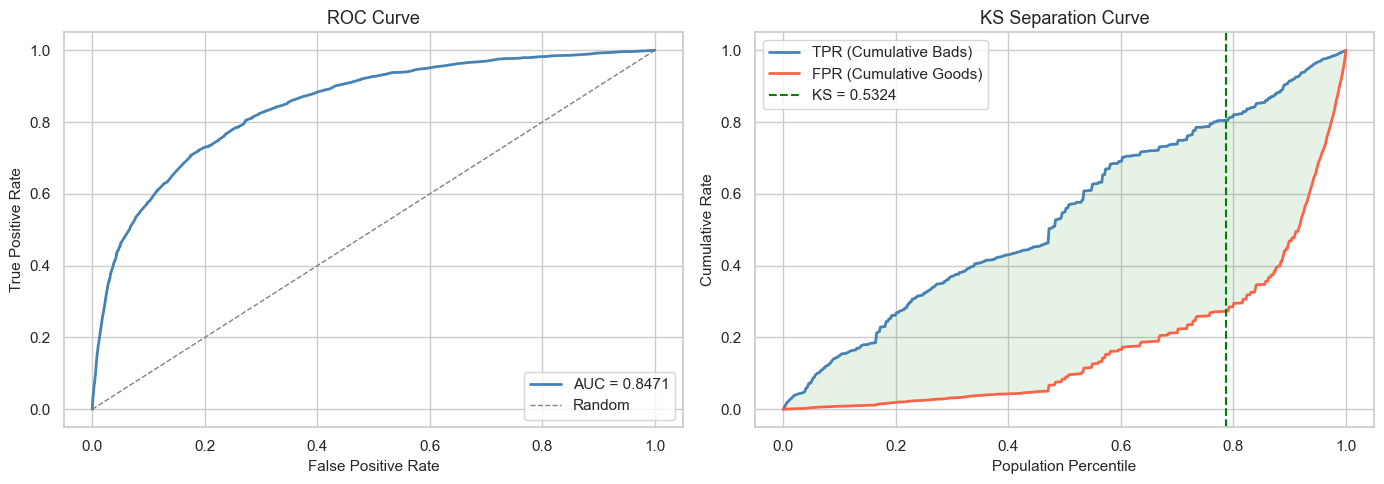

In [21]:
# ROC Curve + KS Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[0].plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

# KS Curve
sorted_idx = np.argsort(thresholds)[::-1]
ks_x       = np.linspace(0, 1, len(tpr))
ks_max_idx = np.argmax(tpr - fpr)

axes[1].plot(ks_x, tpr, color='steelblue', lw=2, label='TPR (Cumulative Bads)')
axes[1].plot(ks_x, fpr, color='tomato',    lw=2, label='FPR (Cumulative Goods)')
axes[1].axvline(ks_x[ks_max_idx], color='green', linestyle='--', lw=1.5,
                label=f'KS = {ks_stat:.4f}')
axes[1].fill_between(ks_x, fpr, tpr, alpha=0.1, color='green')
axes[1].set_xlabel('Population Percentile')
axes[1].set_ylabel('Cumulative Rate')
axes[1].set_title('KS Separation Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

---

## Section 10 — Score Band Analysis


In [22]:
# Assign score bands to full dataset
BAND_BINS   = [-np.inf, 560, 580, 600, 620, 640, np.inf]
BAND_LABELS = ['<560', '560-579', '580-599', '600-619', '620-639', '640+']

df_woe['score_band'] = pd.cut(
    df_woe['score'],
    bins=BAND_BINS,
    labels=BAND_LABELS,
    right=False
)

overall_bad_rate = df_woe['default_flag'].mean()

band_stats = df_woe.groupby('score_band', observed=True).agg(
    volume=('default_flag', 'count'),
    bad_count=('default_flag', 'sum')
).reset_index()

band_stats['bad_rate']     = band_stats['bad_count'] / band_stats['volume']
band_stats['pct_volume']   = band_stats['volume'] / band_stats['volume'].sum()

# Approval rate = cumulative % from top band down
band_stats_rev           = band_stats.iloc[::-1].copy()
band_stats_rev['cum_vol'] = band_stats_rev['volume'].cumsum()
band_stats_rev['approval_rate'] = band_stats_rev['cum_vol'] / band_stats['volume'].sum()
band_stats = band_stats_rev.iloc[::-1].reset_index(drop=True)

band_stats['lift'] = band_stats['bad_rate'] / overall_bad_rate

display_df = band_stats[['score_band', 'volume', 'bad_count', 'bad_rate', 'approval_rate', 'lift']].copy()
display_df['bad_rate']     = display_df['bad_rate'].map('{:.2%}'.format)
display_df['approval_rate'] = display_df['approval_rate'].map('{:.2%}'.format)
display_df['lift']         = display_df['lift'].map('{:.2f}x'.format)

print(f'Overall bad rate: {overall_bad_rate:.2%}')
print('\nScore Band Analysis:')
display_df.style.background_gradient(subset=['volume'], cmap='Blues')

Overall bad rate: 6.68%

Score Band Analysis:


,score_band,volume,bad_count,bad_rate,approval_rate,lift
0,<560,33542,7202,21.47%,100.00%,3.21x
1,560-579,23462,1351,5.76%,77.64%,0.86x
2,580-599,41117,967,2.35%,62.00%,0.35x
3,600-619,41843,446,1.07%,34.59%,0.16x
4,620-639,10035,60,0.60%,6.69%,0.09x


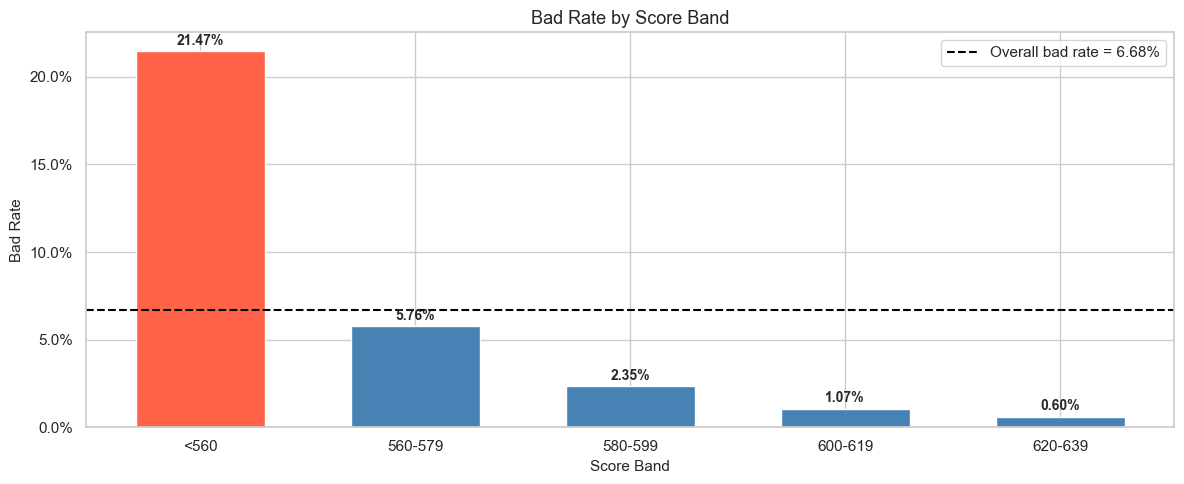

In [23]:
# Score Band Bar Chart — Bad Rate per Band
fig, ax = plt.subplots(figsize=(12, 5))

band_labels_actual = band_stats['score_band'].astype(str).tolist()

bar_colors = ['tomato' if br > overall_bad_rate * 1.5
              else 'gold' if br > overall_bad_rate
              else 'steelblue'
              for br in band_stats['bad_rate']]

bars = ax.bar(band_labels_actual, band_stats['bad_rate'], color=bar_colors, edgecolor='white', width=0.6)
ax.axhline(overall_bad_rate, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall bad rate = {overall_bad_rate:.2%}')

for bar, br in zip(bars, band_stats['bad_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{br:.2%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Score Band')
ax.set_ylabel('Bad Rate')
ax.set_title('Bad Rate by Score Band')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The score bands should show a clear monotonic relationship — lower scores should have higher bad rates. Red bars indicate bands with bad rates significantly above average (high-risk), suitable for decline or heavy manual review. Blue bars indicate below-average bad rates (low-risk), suitable for straight-through approval. The 640+ band should represent the safest applicant segment.

---

## Section 11 — Cutoff Recommendation

We model the approval rate vs bad rate trade-off across all possible score cutoffs. This is the core business decision: setting the cutoff higher rejects more applicants (lower approval rate) but produces a cleaner portfolio (lower bad rate). The optimal cutoff depends on:

- **Business target:** What bad rate is acceptable to the portfolio?
- **Growth target:** What minimum approval rate must we maintain?
- **Cost of risk vs cost of acquisition:** What is the LGD × default probability vs. the revenue per approved account?

We present three candidate cutoffs and recommend a three-tier decision rule.

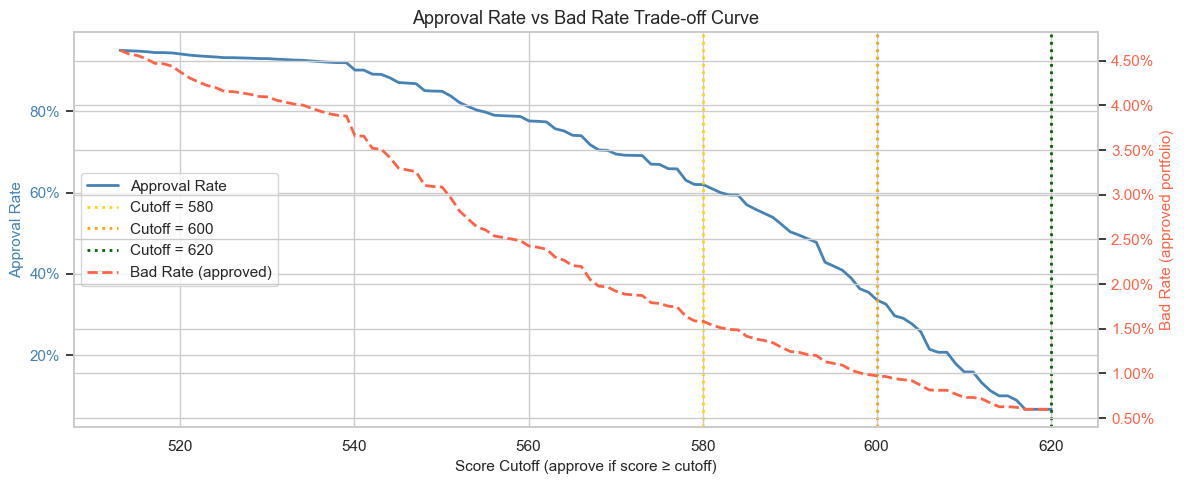

In [24]:
# Approval rate vs Bad rate trade-off curve
cutoffs    = np.arange(df_woe['score'].quantile(0.05), df_woe['score'].quantile(0.95), 1)
approval_rates = []
bad_rates_above = []

for c in cutoffs:
    approved = df_woe[df_woe['score'] >= c]
    approval_rates.append(len(approved) / len(df_woe))
    bad_rates_above.append(approved['default_flag'].mean() if len(approved) > 0 else np.nan)

fig, ax1 = plt.subplots(figsize=(12, 5))

color_approval = 'steelblue'
color_bad      = 'tomato'

ax1.plot(cutoffs, approval_rates, color=color_approval, lw=2, label='Approval Rate')
ax1.set_xlabel('Score Cutoff (approve if score ≥ cutoff)')
ax1.set_ylabel('Approval Rate', color=color_approval)
ax1.tick_params(axis='y', labelcolor=color_approval)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax2 = ax1.twinx()
ax2.plot(cutoffs, bad_rates_above, color=color_bad, lw=2, linestyle='--', label='Bad Rate (approved)')
ax2.set_ylabel('Bad Rate (approved portfolio)', color=color_bad)
ax2.tick_params(axis='y', labelcolor=color_bad)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Mark 3 candidate cutoffs
candidate_cutoffs = [580, 600, 620]
candidate_colors  = ['gold', 'orange', 'darkgreen']
for cc, ccolor in zip(candidate_cutoffs, candidate_colors):
    ax1.axvline(cc, color=ccolor, linestyle=':', lw=2, label=f'Cutoff = {cc}')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

ax1.set_title('Approval Rate vs Bad Rate Trade-off Curve')
plt.tight_layout()
plt.show()

In [25]:
# Decision table: 3 candidate cutoffs
decision_rows = []
for cutoff in [580, 600, 620]:
    approved = df_woe[df_woe['score'] >= cutoff]
    declined = df_woe[df_woe['score'] <  cutoff]
    decision_rows.append({
        'Cutoff':         cutoff,
        'Approval Rate':  f'{len(approved)/len(df_woe):.2%}',
        'Approved Bad Rate': f'{approved["default_flag"].mean():.2%}' if len(approved) > 0 else 'N/A',
        'Declined Volume': f'{len(declined):,}',
        'Strategy':       {580: 'Growth-oriented', 600: 'Balanced', 620: 'Conservative'}[cutoff]
    })

decision_df = pd.DataFrame(decision_rows)
print('Candidate Cutoff Decision Table:')
print(decision_df.to_string(index=False))

print('\n--- Three-Tier Decision Rule (Recommended) ---')
print('Score >= 620  →  APPROVE   (straight-through, low manual cost)')
print('Score 580-619 →  MANUAL REVIEW  (credit officer assessment)')
print('Score <  580  →  DECLINE   (too high risk for portfolio)')

Candidate Cutoff Decision Table:
 Cutoff Approval Rate Approved Bad Rate Declined Volume        Strategy
    580        62.00%             1.58%          57,004 Growth-oriented
    600        34.59%             0.98%          98,121        Balanced
    620         6.69%             0.60%         139,964    Conservative

--- Three-Tier Decision Rule (Recommended) ---
Score >= 620  →  APPROVE   (straight-through, low manual cost)
Score 580-619 →  MANUAL REVIEW  (credit officer assessment)
Score <  580  →  DECLINE   (too high risk for portfolio)


---

## Section 12 — Final Scorecard & Summary

We present the complete production scorecard table — the deliverable that would go to the lending officer. This table is the model in its operational form: no probability, no log-odds, just a printable reference that any branch employee can use to score an applicant manually by summing the relevant row values.

In [26]:
# Final Scorecard Table — formatted for operational use
print('=' * 70)
print('A-SCORE SCORECARD — Give Me Some Credit Dataset')
print(f'Base Score: {BASE_SCORE} | PDO: {PDO} | Base Odds: {BASE_ODDS}:1')
print('=' * 70)

for feat in selected_features:
    subset = scorecard_df[scorecard_df['feature'] == feat].copy()
    print(f'\n  Feature: {feat.upper()}')
    print(f'  {"Bin":<35} {"Bad Rate":<12} {"Count":<10} {"Points":>8}')
    print(f'  {"-"*35} {"-"*12} {"-"*10} {"-"*8}')
    for _, row in subset.iterrows():
        print(f'  {str(row["bin"]):<35} {row["bad_rate"]:<12} {row["count"]:<10,} {row["points"]:>8.1f}')

print('\n' + '=' * 70)
print('DECISION RULE')
print('  Score >= 620  : APPROVE')
print('  Score 580-619 : MANUAL REVIEW')
print('  Score <  580  : DECLINE')
print('=' * 70)

A-SCORE SCORECARD — Give Me Some Credit Dataset
Base Score: 600 | PDO: 20 | Base Odds: 50:1

  Feature: REVOLVING_UTIL
  Bin                                 Bad Rate     Count        Points
  ----------------------------------- ------------ ---------- --------
  (-0.001, 0.00297]                   2.52%        15,000         35.4
  (0.00297, 0.0192]                   1.36%        15,000         47.9
  (0.0192, 0.0435]                    1.40%        15,000         47.3
  (0.0435, 0.0832]                    1.91%        15,000         41.0
  (0.0832, 0.154]                     2.37%        15,000         36.6
  (0.154, 0.271]                      3.47%        14,999         28.8
  (0.271, 0.445]                      5.25%        15,000         20.2
  (0.445, 0.699]                      8.80%        15,000          9.1
  (0.699, 0.981]                      16.58%       15,000         -5.3
  (0.981, 1.0]                        23.17%       15,000        -13.6

  Feature: DPD_90
  Bin     

In [27]:
# Key Metrics Summary Box
print('\n' + '=' * 50)
print('MODEL PERFORMANCE SUMMARY')
print('=' * 50)
print(f'  AUC-ROC          : {auc:.4f}   (benchmark > 0.70)')
print(f'  KS Statistic     : {ks_stat:.4f}   (benchmark > 0.30)')
print(f'  Gini Coefficient : {gini:.4f}   (benchmark > 0.40)')
print(f'  PSI (stability)  : {psi:.4f}   (benchmark < 0.10)')
print('=' * 50)
print(f'  Features selected: {len(selected_features)}')
print(f'  Training rows    : {X_train.shape[0]:,}')
print(f'  Test rows        : {X_test.shape[0]:,}')
print(f'  Overall bad rate : {overall_bad_rate:.2%}')
print('=' * 50)


MODEL PERFORMANCE SUMMARY
  AUC-ROC          : 0.8471   (benchmark > 0.70)
  KS Statistic     : 0.5324   (benchmark > 0.30)
  Gini Coefficient : 0.6941   (benchmark > 0.40)
  PSI (stability)  : 0.0005   (benchmark < 0.10)
  Features selected: 5
  Training rows    : 119,999
  Test rows        : 30,000
  Overall bad rate : 6.68%
